In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["POLARS_MAX_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from xgboost import XGBRegressor
import datetime as dt
from scipy.stats import spearmanr
from tqdm import tqdm
import itertools as it

from typing import Dict

In [ ]:
experiment_name = "all-zscore-1"

# feature derivation and normalization
input_path = "polarity/data/*.parquet"
deriv_win = "7"
zscore_win = "30"

# walk-forward training & inference
start_year = "2020"
enable_1d = True
enable_3d = True
enable_1w = True
enable_2w = True
enable_1m = True
concurrency = "-1"

# backtest
leverage = "1"
top = "0.7"
bottom = "0.1"

In [2]:
horizons: Dict[str, int] = {}
if enable_1d:
    horizons |= {"1d": 1}
if enable_3d:
    horizons |= {"3d": 3}
if enable_1w:
    horizons |= {"1w": 7}
if enable_2w:
    horizons |= {"2w": 14}
if enable_1m:
    horizons |= {"1m": 30}

models = {
    **{f"lin{n}": h for n, h in horizons.items()},
    **{f"gbt{n}": h for n, h in horizons.items()},
    **{f"com{n}": h for n, h in horizons.items()},
}

input_features = [
    # original
    "udpil",
    "udpim",
    "udpis",
    "upprob",
    "mbi",
    "tci",
    # derived
    "tcidelta",
    "mdcdelta",
    # "mom1m",
]

features = [
    *input_features,
    *[f"{f}roc" for f in input_features],
]

feature_path = f"features-{experiment_name}.parquet"
predictions_path = f"predictions-{experiment_name}.parquet"

start_year = int(start_year)

deriv_win = int(deriv_win)
zscore_win = int(zscore_win)
concurrency = int(concurrency)

leverage = float(leverage)
top = float(top)
bottom = float(bottom)

print(
    f"""
Experiment: {experiment_name}

Feature Output: {feature_path}
Prediction Output: {predictions_path}
Input Path: {input_path}

Derivation Window: {deriv_win} days
Z-Score Window: {zscore_win} days
Concurrency: {concurrency} jobs

Prediction Horizons: {', '.join(horizons.keys())}
Input Features: {', '.join(input_features)}
Total Features After Derivation: {len(features)}
"""
)

In [3]:


def rolling_zscore(expr, window):
    return (
        (expr - expr.rolling_mean(window, min_samples=1))
        / expr.rolling_std(window, min_samples=1)
    ).over("symbol")


df = (
    pl.read_parquet(input_path)
    .rename(
        {
            "asset": "symbol",
            "price": "close",
            "timestamp": "ts",
        }
    )
    .with_columns(ts=pl.col("ts").dt.cast_time_unit("us"))
    .sort(["symbol", "ts"])
    # derive pct distance from *cv
    .with_columns(
        tcidelta=rolling_zscore(
            (pl.col("tcicv") - pl.col("close")) / pl.col("close"), zscore_win
        ),
        mdcdelta=rolling_zscore(
            (pl.col("mdccv") - pl.col("close")) / pl.col("close"), zscore_win
        ),
    )
    # derive 1st deriv, shift at most deriv_win, less if not enough history
    .with_columns(
        **{
            f"{col}roc": rolling_zscore(
                pl.col(col)
                - pl.coalesce(
                    [
                        pl.col(col).shift(i).over("symbol")
                        for i in range(deriv_win, -1, -1)
                    ]
                ),
                zscore_win,
            )
            for col in input_features
        }
    )
    # normalize
    .with_columns(**{col: rolling_zscore(pl.col(col), zscore_win) for col in features})
    .select(
        [
            "ts",
            "symbol",
            "close",
            *features,
        ]
    )
)

df.write_parquet(feature_path)

  1%|▉                                                                                                                           | 1184/155516 [00:45<1:53:13, 22.72it/s]/Users/kai/studies/.venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
  1%|█▋                                                                                                                          | 2120/155516 [01:26<2:01:14, 21.09it/s]

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

  1%|█▋                                                                                                                          | 2120/155516 [01:40<2:01:14, 21.09it/s]

In [49]:
from joblib import Parallel, delayed

df = pl.read_parquet(feature_path)

symbols = df["symbol"].unique().sort().to_list()
days = df.filter(pl.col("ts").dt.year() >= start_year)["ts"].unique().sort().to_list()


def train_and_predict(sym, day):
    base_df = df.filter(
        (pl.col("symbol") == sym)
        & (pl.col("ts") <= day)
        & (pl.col("ts").dt.year() >= start_year)
    )
    if base_df.height < 10:
        return None

    train_df = base_df.with_columns(
        **{
            f"target{k}": (
                pl.col("close").shift(-v).log() - pl.col("close").log()
            ).over("symbol")
            for k, v in horizons.items()
        }
    ).sort("ts")

    test_df = train_df.filter(pl.col("ts") == day)
    if test_df.height == 0:
        return None

    pred_row = {
        "ts": test_df["ts"].dt.cast_time_unit("us"),
        "symbol": test_df["symbol"],
    }

    for t, v in horizons.items():
        train_h = train_df.drop_nulls(subset=[f"target{t}"] + features).drop_nans(
            subset=features
        )
        test_h = test_df.drop_nulls(subset=features).drop_nans(subset=features)

        if train_h.height < 10 or test_h.height == 0:
            continue

        X_train, y_train = train_h[features], train_h[f"target{t}"]
        X_test = test_h[features]

        model_lin = LinearRegression(n_jobs=1).fit(
            X_train.to_pandas(), y_train.to_pandas()
        )
        model_gbt = HistGradientBoostingRegressor(
            max_iter=50, max_depth=3, random_state=42
        ).fit(X_train, y_train)
        model_com = HistGradientBoostingRegressor(
            max_iter=50, max_depth=3, random_state=42
        ).fit(X_train, y_train - model_lin.predict(X_train))

        pred_row[f"lin{t}"] = model_lin.predict(X_test)[0]
        pred_row[f"gbt{t}"] = model_gbt.predict(X_test)[0]
        pred_row[f"com{t}"] = (
            model_lin.predict(X_test)[0] + model_com.predict(X_test)[0]
        )

    if len(pred_row) == 2:
        return None
    return pl.DataFrame(pred_row)


pred_frag = Parallel(n_jobs=concurrency)(
    delayed(train_and_predict)(sym, day)
    for sym, day in tqdm(it.product(symbols, days), total=len(symbols) * len(days))
)

pred_df = (
    pl.concat([p for p in pred_frag if p is not None], how="diagonal")
    .sort(["ts", "symbol"])
    .group_by(["ts", "symbol"])
    .agg(pl.all().first(ignore_nulls=True))
)
pred_df.write_parquet(predictions_path)

ts,symbol,lin1d,gbt1d,com1d,lin3d,gbt3d,com3d,lin1w,gbt1w,com1w
datetime[μs],str,f64,f64,f64,f64,f64,f64,f64,f64,f64
2020-01-12 00:00:00,"""eth""",-0.023053,0.009392,-0.023053,null,null,null,null,null,null
2020-01-11 00:00:00,"""xtz""",0.002148,-0.004952,0.002148,null,null,null,null,null,null
2020-01-11 00:00:00,"""qnt""",0.717978,-0.025635,0.717978,null,null,null,null,null,null
2020-01-17 00:00:00,"""xmr""",0.006838,0.025716,0.006838,0.561964,0.076969,0.561964,0.747136,0.137446,0.747136
2020-01-18 00:00:00,"""ada""",0.166051,0.017429,0.166051,0.246272,0.054332,0.246272,1.46554,0.111924,1.46554
…,…,…,…,…,…,…,…,…,…,…
2020-01-12 00:00:00,"""ltc""",0.080634,0.0193,0.080634,null,null,null,null,null,null
2020-01-12 00:00:00,"""cro""",0.010377,0.017196,0.010377,null,null,null,null,null,null
2020-01-18 00:00:00,"""fet""",0.116005,0.004094,0.116005,0.174699,0.015411,0.174699,-0.194753,0.031008,-0.194753


In [8]:
(
    pl.read_parquet(feature_path)
    .join(pl.read_parquet(predictions_path), on=["ts", "symbol"], how="inner")
    .sort(["symbol", "ts"])
    .drop_nans()
    .drop_nulls()
    .group_by("symbol")
    .agg(
        lin1d=pl.corr(
            pl.col("close").log().diff().shift(1).over("symbol"), pl.col("lin1d")
        ),
        gbt1d=pl.corr(
            pl.col("close").log().diff().shift(1).over("symbol"), pl.col("gbt1d")
        ),
        com1d=pl.corr(
            pl.col("close").log().diff().shift(1).over("symbol"), pl.col("com1d")
        ),
        lin3d=pl.corr(
            pl.col("close").log().diff(n=3).shift(1).over("symbol"), pl.col("lin3d")
        ),
        gbt3d=pl.corr(
            pl.col("close").log().diff(n=3).shift(1).over("symbol"), pl.col("gbt3d")
        ),
        com3d=pl.corr(
            pl.col("close").log().diff(n=3).shift(1).over("symbol"), pl.col("com3d")
        ),
        lin1w=pl.corr(
            pl.col("close").log().diff(n=7).shift(1).over("symbol"), pl.col("lin1w")
        ),
        gbt1w=pl.corr(
            pl.col("close").log().diff(n=7).shift(1).over("symbol"), pl.col("gbt1w")
        ),
        com1w=pl.corr(
            pl.col("close").log().diff(n=7).shift(1).over("symbol"), pl.col("com1w")
        ),
        lin2w=pl.corr(
            pl.col("close").log().diff(n=14).shift(1).over("symbol"), pl.col("lin2w")
        ),
        gbt2w=pl.corr(
            pl.col("close").log().diff(n=14).shift(1).over("symbol"), pl.col("gbt2w")
        ),
        com2w=pl.corr(
            pl.col("close").log().diff(n=14).shift(1).over("symbol"), pl.col("com2w")
        ),
        lin1m=pl.corr(
            pl.col("close").log().diff(n=30).shift(1).over("symbol"), pl.col("lin1m")
        ),
        gbt1m=pl.corr(
            pl.col("close").log().diff(n=30).shift(1).over("symbol"), pl.col("gbt1m")
        ),
        com1m=pl.corr(
            pl.col("close").log().diff(n=30).shift(1).over("symbol"), pl.col("com1m")
        ),
    )
    .mean()
    .unpivot()
    .filter(pl.col("variable") != "symbol")
    .sort("value")
)

variable,value
str,str
"""gbt1m""","""-0.03046826372720893"""
"""com1m""","""-0.05832519904649068"""
"""lin1m""","""-0.06725555207100957"""
"""lin1d""","""0.009072702654361805"""
"""com1w""","""0.012332531796882531"""
…,…
"""lin2w""","""0.042360398372025106"""
"""gbt1w""","""0.0495436438425116"""
"""gbt2w""","""0.06899386389092724"""


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2277/2277 [00:05<00:00, 385.04it/s]


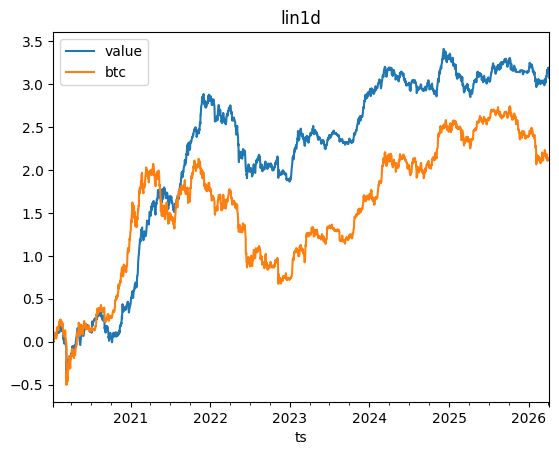

In [4]:
from math import log

df = pl.read_parquet(feature_path).join(
    pl.read_parquet(predictions_path), on=["ts", "symbol"], how="inner"
)

prices_df = df.pivot(index="ts", on="symbol", values="close").sort("ts")
prices_df = prices_df.fill_null(strategy="forward")
prices = prices_df.to_pandas().set_index("ts")

res_frag = []
trades_frag = []

for model, hold_win in models.items():
    portfolio: list[dict] = []
    last_rebalance_date = None

    capital = 1.0
    prev_port_value = 1.0

    days = (
        df.filter(pl.col("ts").dt.year() >= start_year)["ts"].unique().sort().to_list()
    )

    for today in tqdm(days):
        # 1. Update portfolio value
        port_value = 0.0
        if not portfolio:
            port_value = capital
        else:
            for pos in portfolio:
                close = prices.at[today, pos["symbol"]]
                if pd.isna(close):
                    close = pos["open_price"]

                if pos["direction"] == 1:
                    pos_value = pos["capital"] * (close / pos["open_price"])
                else:
                    pos_value = pos["capital"] * (2 - close / pos["open_price"])
                port_value += pos_value

        if port_value <= 0:
            daily_logret = np.nan
        else:
            try:
                daily_logret = log(port_value / prev_port_value)
            except:
                daily_logret = np.nan

        prev_port_value = port_value

        res_frag.append(
            pl.DataFrame(
                {
                    "ts": today,
                    "logret": daily_logret,
                    "model": model,
                },
                schema={"ts": pl.Datetime, "logret": pl.Float32, "model": pl.Utf8},
            )
        )

        # 2. Rebalance logic
        if (
            last_rebalance_date is None
            or (today - last_rebalance_date).days >= hold_win
            or today == days[-1]
        ):
            # Close existing portfolio if any
            if portfolio:
                for pos in portfolio:
                    close = prices.at[today, pos["symbol"]]
                    if pd.isna(close):
                        close = pos["open_price"]
                    if pos["direction"] == 1:
                        ret = close / pos["open_price"]
                    else:
                        ret = 2 - close / pos["open_price"]
                    trades_frag.append(
                        pl.DataFrame(
                            {
                                "symbol": [pos["symbol"]],
                                "open": [pos["open_date"]],
                                "close": [today],
                                "logret": [log(max(ret, 1e-6))],
                                "direction": [pos["direction"]],
                                "model": model,
                            },
                            schema={
                                "symbol": pl.Utf8,
                                "open": pl.Datetime,
                                "close": pl.Datetime,
                                "logret": pl.Float32,
                                "direction": pl.Int8,
                                "model": pl.Utf8,
                            },
                        )
                    )

            # Realize capital
            capital = port_value
            portfolio = []

            # Open new positions immediately at today's close
            cs_df = df.filter((pl.col("ts") == today) & pl.col(model).is_not_null())
            if cs_df.height > 0:
                cs_df = cs_df.with_columns(
                    rank=pl.col(model).rank() / pl.col(model).count()
                )
                long = cs_df.filter((pl.col("rank") >= top) & (pl.col(model) > 0))
                short = cs_df.filter((pl.col("rank") <= bottom) & (pl.col(model) < 0))

                num_positions = long.height + short.height
                if num_positions > 0:
                    w = leverage / num_positions
                    for row in long.iter_rows(named=True):
                        portfolio.append(
                            {
                                "symbol": row["symbol"],
                                "open_date": today,
                                "open_price": row["close"],
                                "direction": 1,
                                "capital": capital * w,
                                "model": model,
                            }
                        )
                    for row in short.iter_rows(named=True):
                        portfolio.append(
                            {
                                "symbol": row["symbol"],
                                "open_date": today,
                                "open_price": row["close"],
                                "direction": -1,
                                "capital": capital * w,
                                "model": model,
                            }
                        )

            last_rebalance_date = today

if len(trades_frag) > 0:
    trades_df = pl.concat(trades_frag)
else:
    trades_df = pl.DataFrame(
        schema={
            "symbol": pl.Utf8,
            "open": pl.Datetime,
            "close": pl.Datetime,
            "logret": pl.Float32,
            "direction": pl.Int8,
            "model": pl.Utf8,
        }
    )
res_df = pl.concat(res_frag)

for model in models:
    (
        res_df.filter(pl.col("model") == model)
        .join(
            df.filter(pl.col("symbol") == "btc").select(
                ts=pl.col("ts").dt.cast_time_unit("us"),
                btc=pl.col("close").log().diff(),
            ),
            on="ts",
            how="inner",
        )
        .drop_nans()
        .with_columns(
            btc=pl.col("btc").cum_sum(),
            value=pl.col("logret").cum_sum(),
        )
        .filter(pl.col("ts").dt.year() >= start_year)
        .to_pandas()
    ).plot(y=["value", "btc"], x="ts", title=model)